# Whisper Large-v3-Turbo: GPU-Accelerated Automatic Speech Recognition

This notebook demonstrates an end-to-end automatic speech recognition (ASR) pipeline using OpenAI's `whisper-large-v3-turbo` model through the Hugging Face Transformers ecosystem.

The workflow covers model and audio asset preparation, device and precision selection, pretrained model loading, pipeline construction, audio discovery, timestamped transcription, runtime measurement, transcription inspection, and structured result export.

**Key Components:**

1. **Environment Setup:** Installs the required Hugging Face and audio-processing dependencies.
2. **Remote Audio Retrieval:** Downloads the audio asset from a Hugging Face Hub dataset repository and stores a local working copy.
3. **Hardware-Aware Inference:** Automatically selects CUDA/FP16 when a GPU is available and falls back to CPU/FP32 otherwise.
4. **Whisper Inference:** Uses `whisper-large-v3-turbo` with chunked processing and timestamp generation.
5. **Structured Output:** Stores the transcription and timestamp chunks in a tabular format and exports the results to CSV.
6. **Inference Diagnostics:** Reports model size, audio properties, processing time, and basic runtime characteristics.


In [ ]:
!pip install -q --upgrade pip
!pip install -q --upgrade transformers datasets[audio] accelerate soundfile

## 1. Imports & Experiment Configuration

The experiment configuration is kept explicit so that the model, input asset, output location, and runtime behavior can be reproduced.

The Hugging Face repository is treated as the source of the audio asset, while the local `/content/audio` directory is used as the inference workspace.


In [ ]:
import os
import json
import shutil
import time
from pathlib import Path

import torch
import pandas as pd
import soundfile as sf

from huggingface_hub import hf_hub_download
from transformers import AutoModelForSpeechSeq2Seq, AutoProcessor, pipeline

MODEL_ID = "openai/whisper-large-v3-turbo"
HF_REPO_ID = "WasiqSaleem/Portfolio_Assest"
AUDIO_FILENAME = "harvard.wav"
AUDIO_FOLDER = Path("/content/audio")
OUTPUT_CSV = Path("/content/whisper_large_v3_turbo_transcription.csv")
OUTPUT_JSON = Path("/content/whisper_large_v3_turbo_transcription.json")

AUDIO_FOLDER.mkdir(parents=True, exist_ok=True)

print("Model:", MODEL_ID)
print("Audio repository:", HF_REPO_ID)
print("Audio file:", AUDIO_FILENAME)


Model: openai/whisper-large-v3-turbo
Audio repository: WasiqSaleem/Portfolio_Assest
Audio file: harvard.wav


## 2. Downloading the Audio Asset

The input audio is retrieved directly from the specified Hugging Face Hub dataset repository.

A local copy is created only when the file is not already present in the working directory. This avoids unnecessary repeated file operations when the notebook is re-executed.


In [ ]:
print("Downloading audio asset...")

cached_audio = hf_hub_download(
    repo_id=HF_REPO_ID,
    filename=AUDIO_FILENAME,
    repo_type="dataset"
)

AUDIO_PATH = AUDIO_FOLDER / AUDIO_FILENAME

if not AUDIO_PATH.exists():
    shutil.copy2(cached_audio, AUDIO_PATH)

print(f"Audio ready: {AUDIO_PATH}")
print(f"File size: {AUDIO_PATH.stat().st_size / (1024 ** 2):.2f} MB")


Audio ready: /content/audio/harvard.wav
File size: 3.10 MB


## 3. Audio Input Inspection

Before inference, the audio properties are inspected explicitly.

The sampling rate, number of channels, number of samples, and duration provide a basic sanity check that the input was loaded correctly and give useful context for interpreting inference time.


In [ ]:
audio_info = sf.info(AUDIO_PATH)

audio_duration = audio_info.duration
audio_sample_rate = audio_info.samplerate
audio_channels = audio_info.channels
audio_frames = audio_info.frames

print("Audio format:", audio_info.format)
print("Sampling rate:", f"{audio_sample_rate:,} Hz")
print("Channels:", audio_channels)
print("Frames:", f"{audio_frames:,}")
print("Duration:", f"{audio_duration:.2f} seconds")


Audio format: WAV
Sampling rate: 44,100 Hz
Channels: 2
Frames: 809,508
Duration: 18.36 seconds


## 4. Device & Precision Selection

Whisper inference is computationally expensive, so the notebook selects the available hardware automatically.

CUDA inference uses FP16 to reduce memory consumption and improve throughput on compatible GPUs. CPU inference falls back to FP32 for compatibility.

The selected device and precision are printed so the experimental environment is visible rather than implicit.


In [ ]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    TORCH_DTYPE = torch.float16
    PIPELINE_DEVICE = 0
    print("CUDA GPU detected.")
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print("Using FP16.")
else:
    device = torch.device("cpu")
    TORCH_DTYPE = torch.float32
    PIPELINE_DEVICE = -1
    print("CUDA GPU not available.")
    print("Using CPU with FP32.")

print("Device:", device)
print("Torch dtype:", TORCH_DTYPE)


CUDA GPU detected.
GPU: Tesla T4
Using FP16.
Device: cuda
Torch dtype: torch.float16


## 5. Loading Whisper Large-v3-Turbo

The pretrained `whisper-large-v3-turbo` checkpoint is loaded with the precision selected for the current hardware.

The model is explicitly moved to the selected device and switched to evaluation mode because this notebook performs inference rather than parameter updates.


In [ ]:
print(f"\nLoading {MODEL_ID}...")

model = AutoModelForSpeechSeq2Seq.from_pretrained(
    MODEL_ID,
    torch_dtype=TORCH_DTYPE,
    low_cpu_mem_usage=True
)

model = model.to(device)
model.eval()

processor = AutoProcessor.from_pretrained(MODEL_ID)

total_parameters = sum(parameter.numel() for parameter in model.parameters())

print("Model loaded successfully.")
print("Total parameters:", f"{total_parameters:,}")
print("Model device:", next(model.parameters()).device)
print("Model dtype:", next(model.parameters()).dtype)



Loading openai/whisper-large-v3-turbo...


Loading weights:   0%|          | 0/587 [00:00<?, ?it/s]

Model loaded successfully.
Total parameters: 808,878,080
Model device: cuda:0
Model dtype: torch.float16


## 6. Automatic Speech Recognition Pipeline

The Hugging Face ASR pipeline connects the Whisper model with its tokenizer and feature extractor.

`chunk_length_s=30` processes long audio in manageable segments, while `return_timestamps=True` preserves temporal information for each decoded chunk.

A batch size of 4 is used for chunk processing when the available hardware can support it.


In [ ]:
asr_pipe = pipeline(
    "automatic-speech-recognition",
    model=model,
    tokenizer=processor.tokenizer,
    feature_extractor=processor.feature_extractor,
    device=PIPELINE_DEVICE,
    chunk_length_s=30,
    batch_size=4
)

[transformers] Using `chunk_length_s` is very experimental with seq2seq models. The results will not necessarily be entirely accurate and will have caveats. More information: https://github.com/huggingface/transformers/pull/20104. Ignore this warning with pipeline(..., ignore_warning=True). To use Whisper for long-form transcription, use rather the model's `generate` method directly as the model relies on it's own chunking mechanism (cf. Whisper original paper, section 3.8. Long-form Transcription).


## 7. Audio File Discovery

The working directory is scanned for supported audio formats rather than hard-coding the inference loop around a single file.

This makes the same pipeline reusable when additional audio assets are placed in the input directory.


In [ ]:
SUPPORTED_EXTENSIONS = (".mp3", ".wav", ".flac", ".m4a", ".ogg")

audio_files = [
    str(file)
    for file in AUDIO_FOLDER.iterdir()
    if file.is_file() and file.suffix.lower() in SUPPORTED_EXTENSIONS
]

print(f"\nFound {len(audio_files)} audio file(s).")

for file_path in audio_files:
    print(f" - {os.path.basename(file_path)}")



Found 1 audio file(s).
 - harvard.wav


## 8. Timestamped Speech Recognition

Each discovered audio file is passed through the Whisper ASR pipeline.

The transcription text is retained together with the timestamped chunks. Runtime is measured separately for each file so that inference cost can be related to the input duration.

Errors are captured per file so that one failed input does not terminate processing of the remaining audio assets.


In [ ]:
results = []
if audio_files:
    _ = asr_pipe(audio_files[0], return_timestamps=True)
    if device.type == "cuda":
        torch.cuda.synchronize()
    print("Warm-up inference completed (excluded from timing).")

for file_path in audio_files:
    filename = os.path.basename(file_path)
    file_info = sf.info(file_path)
    duration = file_info.duration

    print(f"\nProcessing: {filename}")
    print(f"Duration: {duration:.2f} seconds")

    if device.type == "cuda":
        torch.cuda.synchronize()
    start_time = time.perf_counter()

    try:
        transcription = asr_pipe(
            file_path,
            return_timestamps=True
        )

        if device.type == "cuda":
            torch.cuda.synchronize()
        elapsed_time = time.perf_counter() - start_time
        realtime_factor = elapsed_time / duration if duration > 0 else float("nan")
        chunks = transcription.get("chunks", [])

        chunks_str = json.dumps(
            chunks,
            ensure_ascii=False,
            default=str
        )

        results.append({
            "file": filename,
            "duration_seconds": duration,
            "inference_time_seconds": elapsed_time,
            "real_time_factor": realtime_factor,
            "transcription": transcription["text"],
            "chunks": chunks_str
        })

        print("Transcription completed.")
        print(f"Inference time: {elapsed_time:.2f} seconds")
        print(f"Real-time factor: {realtime_factor:.3f}")
        print(f"Text: {transcription['text']}")

    except Exception as e:
        elapsed_time = time.perf_counter() - start_time

        print(f"Error processing {filename}: {e}")

        results.append({
            "file": filename,
            "duration_seconds": duration,
            "inference_time_seconds": elapsed_time,
            "real_time_factor": float("nan"),
            "transcription": f"ERROR: {str(e)}",
            "chunks": ""
        })

print(f"\nFinished processing {len(results)} file(s).")


Warm-up inference completed (excluded from timing).

Processing: harvard.wav
Duration: 18.36 seconds
Transcription completed.
Inference time: 1.84 seconds
Real-time factor: 0.100
Text:  The stale smell of old beer lingers. It takes heat to bring out the odor. A cold dip restores health and zest. A salt pickle tastes fine with ham. Tacos al pastor are my favorite. A zestful food is the hot cross bun.

Finished processing 1 file(s).


## 9. Transcription Results

The transcription output is converted into a DataFrame so that each audio file has a structured record containing its duration, inference time, real-time factor, transcription, and timestamp information.

The real-time factor is defined as:

`inference time / audio duration`

A value below 1.0 means the system processed the audio faster than real time.


In [ ]:
df = pd.DataFrame(results)

print("Transcription results:")
display(df)


Transcription results:


,file,duration_seconds,inference_time_seconds,real_time_factor,transcription,chunks
0,harvard.wav,18.35619,1.843333,0.10042,The stale smell of old beer lingers. It takes...,"[{""timestamp"": [0.8, 3.62], ""text"": "" The stal..."


## 10. Inspecting Timestamped Chunks

Whisper can return timestamp information for the decoded segments.

Inspecting the chunks provides more detailed evidence than viewing only the final transcription string because it exposes how the model aligned portions of the generated text with the audio timeline.


In [ ]:
for result in results:
    if not result["chunks"]:
        continue

    chunks = json.loads(result["chunks"])

    print(f"\nFile: {result['file']}")
    print(f"Number of timestamped chunks: {len(chunks)}")

    for chunk in chunks:
        timestamp = chunk.get("timestamp")
        text = chunk.get("text", "").strip()
        print(f"{timestamp}: {text}")



File: harvard.wav
Number of timestamped chunks: 6
[0.8, 3.62]: The stale smell of old beer lingers.
[4.42, 6.2]: It takes heat to bring out the odor.
[7.04, 9.36]: A cold dip restores health and zest.
[9.98, 12.06]: A salt pickle tastes fine with ham.
[12.66, 14.36]: Tacos al pastor are my favorite.
[15.12, 17.5]: A zestful food is the hot cross bun.


## 11. Saving Structured Results

The final transcription table is saved as CSV for convenient downstream analysis.

The complete structured result, including timestamped chunks, is also saved as JSON so that the temporal transcription information is preserved without flattening it into a table.


In [ ]:
df.to_csv(
    OUTPUT_CSV,
    index=False,
    encoding="utf-8"
)

with open(OUTPUT_JSON, "w", encoding="utf-8") as file:
    json.dump(
        results,
        file,
        ensure_ascii=False,
        indent=2,
        default=str
    )

print(f"Transcriptions saved to: {OUTPUT_CSV}")
print(f"Timestamped results saved to: {OUTPUT_JSON}")


Transcriptions saved to: /content/whisper_large_v3_turbo_transcription.csv
Timestamped results saved to: /content/whisper_large_v3_turbo_transcription.json


## 12. Inference Summary

The final summary reports the number of processed files, total audio duration, total inference time, and aggregate real-time factor.

These measurements provide a basic reproducibility and efficiency profile for the ASR experiment.


In [ ]:
successful_results = [
    result for result in results
    if not result["transcription"].startswith("ERROR:")
]

total_duration = sum(
    result["duration_seconds"]
    for result in successful_results
)

total_inference_time = sum(
    result["inference_time_seconds"]
    for result in successful_results
)

overall_rtf = (
    total_inference_time / total_duration
    if total_duration > 0
    else float("nan")
)

print("Successful files:", len(successful_results))
print("Total audio duration:", f"{total_duration:.2f} seconds")
print("Total inference time:", f"{total_inference_time:.2f} seconds")
print("Overall real-time factor:", f"{overall_rtf:.3f}")
if len(successful_results) < 5:
    print("RTF is based on a single/small sample and should not be treated as a stable throughput benchmark.")

Successful files: 1
Total audio duration: 18.36 seconds
Total inference time: 1.84 seconds
Overall real-time factor: 0.100
RTF is based on a single/small sample and should not be treated as a stable throughput benchmark.


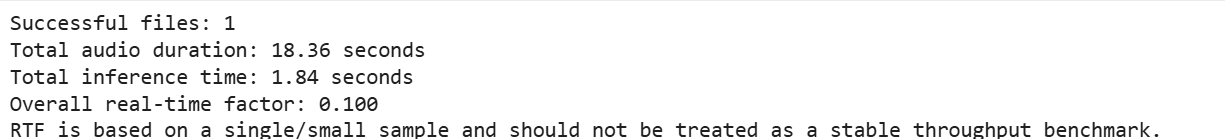

# Research Interpretation and Limitations

The experiment demonstrates a complete ASR inference pipeline using the pretrained whisper-large-v3-turbo model, including audio validation, hardware selection, transcription, timestamps, runtime measurement, and result export.

The system processed 18.36 seconds of audio in 1.84 seconds, achieving an RTF of 0.100, meaning the audio was processed approximately 10 times faster than real time.

However, the model was not fine-tuned, so the experiment evaluates inference and deployment rather than task-specific training. Also, only one audio sample was tested, so the RTF cannot be considered a general performance benchmark.

Since no ground-truth transcript was available, WER/CER accuracy metrics could not be calculated. Future work should evaluate multiple audio samples with reference transcripts and compare different hardware, model configurations, and decoding settings.

Overall, the experiment provides a practical demonstration of efficient modern ASR inference, from audio input through transcription, timestamps, performance evaluation, and structured output.